# Adjustability Results

**Adjustability** metric (`src/adjustability.py` → `data/adjustability.parquet`): how much a hitter reshapes his swing by situation, net of pitch location. This notebook shows the leaderboard and visualizes whether adjustability pays off (`src/payoff.py` → `results/payoff.md`).

In [1]:
# Setup: paths + theme shared by the cells below. The leaderboard is rendered by R
# (src/leaderboard_table.R); the payoff coefficient forest plots are parsed from results/payoff.md.
from pathlib import Path
import pandas as pd

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
PLOTS = ROOT / 'results' / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

# fivethirtyeight on a white background (grid color set explicitly; FT's default grid is white).
FT = ['fivethirtyeight', {'figure.facecolor': 'white', 'axes.facecolor': 'white',
                          'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'}]


def plot_path(name):
    """Route a figure filename to its results/plots/<category> subfolder (mirrored in the R
    generator and the other results notebooks)."""
    sub = 'adjustability' if name.startswith('adjustability') else 'predictiveness'
    d = PLOTS / sub
    d.mkdir(parents=True, exist_ok=True)
    return d / name

## Why we must net out pitch location first

Adjustability asks whether a hitter changes his swing *by situation*. The threat to that claim is **pitch location**: where the ball is already dictates the swing, and location is **not evenly distributed across situations** (pitchers work differently with two strikes). So a naive "his swing differs by situation" signal is partly just "he saw different pitches." Two panels establish the confound, which is why the metric residualizes location *before* measuring adjustment:

1. **The swing is set by location** — mean swing geometry varies sharply across the strike zone (location alone explains ~41% of swing length and ~46% of swing tilt).
2. **Location shifts with the situation** — two-strike pitches expand out of the zone's middle.

Location drives the swing *and* moves with the count, so any situation signal measured without controlling location is contaminated by it.

632,203 competitive swings, [2024, 2025]
  location explains 11.7% of bat_speed
  location explains 40.8% of swing_length
  location explains 45.8% of swing_path_tilt


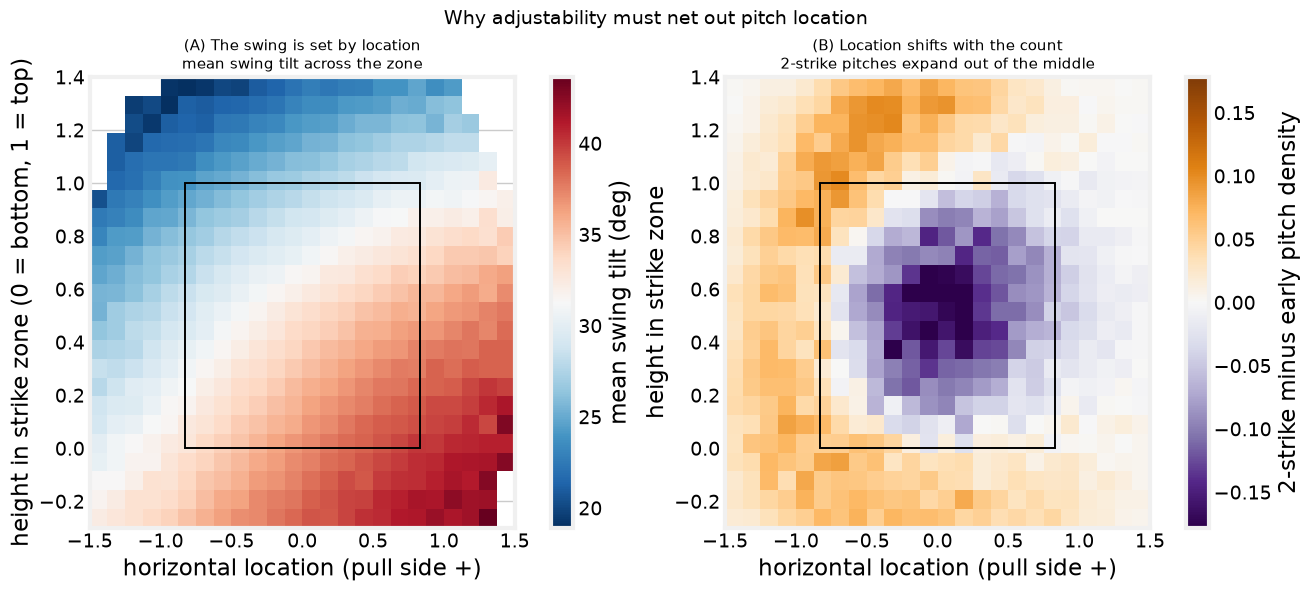

In [2]:
# ---- Defense figure: why the location confound must be controlled ----
# (A) the swing dials are set by pitch location; (B) pitch location shifts with the situation
# (2-strike pitches expand out of the zone's middle). Together: the swing is largely dictated by where
# the pitch is, and where the pitch is depends on the situation -- so a raw "his swing differs by
# situation" signal is confounded by location, which is why the metric nets location out first.
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, str(ROOT / 'src'))
from adjustability import add_context, location_design, DIALS, KEY, SEASONS

cols = (['game_year', 'batter_full_name'] + KEY + ['balls', 'strikes', 'outs_when_up', 'plate_x',
        'plate_z', 'sz_top', 'sz_bot', 'pitch_type', 'on_1b_id', 'on_2b_id', 'on_3b_id'] + DIALS)
df = add_context(pd.read_parquet(DATA / 'swings_model.parquet', columns=cols).query('game_year in @SEASONS'))
print(f'{len(df):,} competitive swings, {SEASONS}')

# how much of each dial does location alone explain, league-wide? (the panel-A headline number)
Lall = location_design(df)
for d in DIALS:
    b, *_ = np.linalg.lstsq(Lall, df[d].to_numpy(float), rcond=None)
    r2 = 1 - ((df[d] - Lall @ b) ** 2).sum() / ((df[d] - df[d].mean()) ** 2).sum()
    print(f'  location explains {r2 * 100:4.1f}% of {d}')

xb = np.linspace(-1.5, 1.5, 25)
yb = np.linspace(-0.3, 1.4, 25)
ZONE = dict(xy=(-0.83, 0.0), width=1.66, height=1.0)   # approx strike zone in (px, normalized pz)

with plt.style.context(FT):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.8), constrained_layout=True)

    # (A) mean swing tilt across the zone -- location sets the swing geometry
    zdial = 'swing_path_tilt'
    xi, yi = np.digitize(df.px, xb) - 1, np.digitize(df.pz, yb) - 1
    v = df[zdial].to_numpy(float)
    stat = np.full((len(yb) - 1, len(xb) - 1), np.nan)
    for i in range(len(yb) - 1):
        for j in range(len(xb) - 1):
            m = (xi == j) & (yi == i)
            if m.sum() >= 40:
                stat[i, j] = v[m].mean()
    im = axA.pcolormesh(xb, yb, stat, cmap='RdBu_r', shading='flat')
    axA.add_patch(plt.Rectangle(**ZONE, fill=False, edgecolor='k', lw=1.4))
    fig.colorbar(im, ax=axA, label='mean swing tilt (deg)')
    axA.set_title('(A) The swing is set by location\nmean swing tilt across the zone', fontsize=11)
    axA.set_xlabel('horizontal location (pull side +)')
    axA.set_ylabel('height in strike zone (0 = bottom, 1 = top)')

    # (B) where 2-strike pitches concentrate vs earlier counts (density difference)
    twok, early = df[df.strikes == 2], df[df.strikes < 2]
    H2, _, _ = np.histogram2d(twok.px, twok.pz, bins=[xb, yb], density=True)
    H0, _, _ = np.histogram2d(early.px, early.pz, bins=[xb, yb], density=True)
    diff = (H2 - H0).T
    lim = np.nanpercentile(np.abs(diff), 99)
    im2 = axB.pcolormesh(xb, yb, diff, cmap='PuOr_r', vmin=-lim, vmax=lim, shading='flat')
    axB.add_patch(plt.Rectangle(**ZONE, fill=False, edgecolor='k', lw=1.4))
    fig.colorbar(im2, ax=axB, label='2-strike minus early pitch density')
    axB.set_title('(B) Location shifts with the count\n2-strike pitches expand out of the middle', fontsize=11)
    axB.set_xlabel('horizontal location (pull side +)')
    axB.set_ylabel('height in strike zone')

    fig.suptitle('Why adjustability must net out pitch location', fontsize=14)
    fig.savefig(plot_path('adjustability_location_confound.png'), dpi=130)
    plt.show()

# Does adjustability exist, and how much?

Before asking whether adjustability *pays off*, confirm it is real. Three views: the raw behavior (do hitters actually change their swing by count?), the spread across hitters (how much does it vary?), and year-to-year stability (a repeatable skill, or just noise?).

## The behavior: hitters compress their swing with two strikes

The most direct evidence that adjustment happens at all — league-wide, as the count reaches two strikes, hitters swing **slower, shorter, and flatter**. This is descriptive (raw means); the metric's job is to isolate the part of this that is a deliberate choice rather than just the different pitches thrown in two-strike counts.

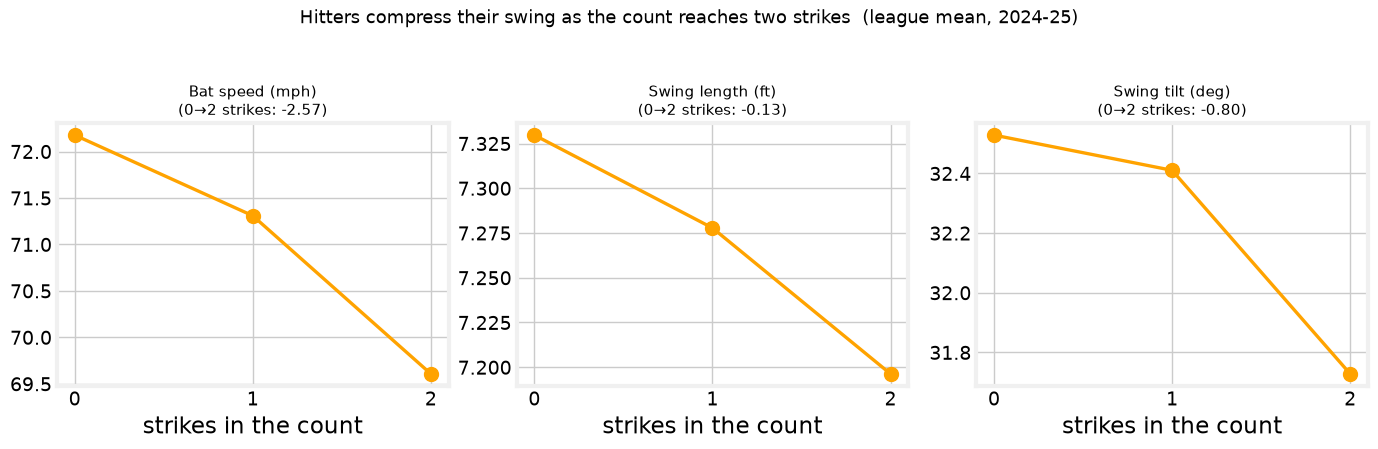

In [3]:
# League-mean swing dials by strike count -- the raw two-strike compression the metric captures.
import numpy as np
import matplotlib.pyplot as plt
from adjustability import DIALS  # bat_speed, swing_length, swing_path_tilt

sm = pd.read_parquet(DATA / 'swings_model.parquet',
                     columns=['game_year', 'strikes'] + DIALS).query('game_year in [2024, 2025]')
prof = sm.groupby('strikes')[DIALS].mean()
labels = {'bat_speed': 'Bat speed (mph)', 'swing_length': 'Swing length (ft)',
          'swing_path_tilt': 'Swing tilt (deg)'}
with plt.style.context(FT):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
    for ax, d in zip(axes, DIALS):
        y = prof[d].values
        ax.plot([0, 1, 2], y, '-o', color='#FFA300', lw=2.4, markersize=10)
        ax.set_xticks([0, 1, 2])
        ax.set_xlabel('strikes in the count')
        ax.set_title(f'{labels[d]}\n(0→2 strikes: {y[2] - y[0]:+.2f})', fontsize=11)
    fig.suptitle('Hitters compress their swing as the count reaches two strikes  (league mean, 2024-25)',
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(plot_path('adjustability_behavior_by_count.png'), dpi=130)
    plt.show()

## How much: the spread across hitters

Each qualified hitter gets one adjustability score. Adjustment is nearly **universal** — almost no one sits at zero — but the *extent* varies widely: the most adjustable hitters score two to three times the median.

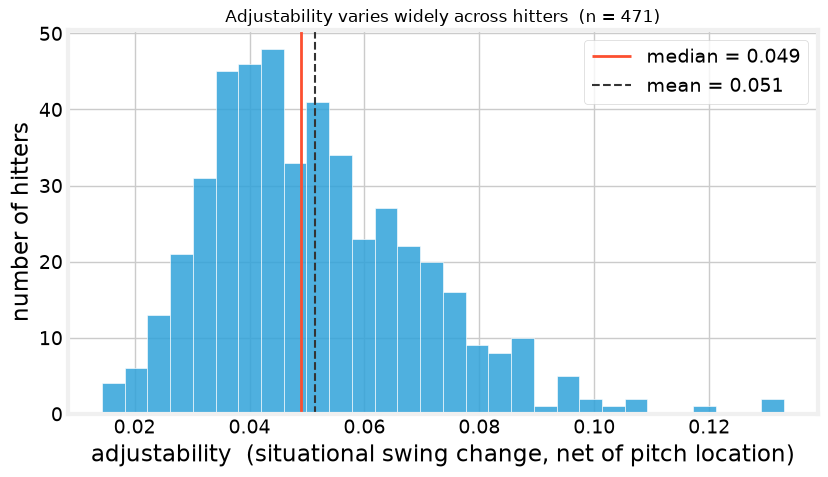

range 0.014-0.133, mean 0.051, median 0.049, share < 0.02: 1.1%


In [4]:
# Distribution of the headline adjustability score across the 471 qualified hitter-stances.
import numpy as np
import matplotlib.pyplot as plt

adj = pd.read_parquet(DATA / 'adjustability.parquet', columns=['adjustability'])
mn, md_ = adj.adjustability.mean(), adj.adjustability.median()
with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.hist(adj['adjustability'], bins=30, color='#30a2da', alpha=.85, edgecolor='white')
    ax.axvline(md_, color='#fc4f30', lw=2, label=f'median = {md_:.3f}')
    ax.axvline(mn, color='#333333', lw=1.5, ls='--', label=f'mean = {mn:.3f}')
    ax.set_xlabel('adjustability  (situational swing change, net of pitch location)')
    ax.set_ylabel('number of hitters')
    ax.set_title(f'Adjustability varies widely across hitters  (n = {len(adj)})', fontsize=12)
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_path('adjustability_distribution.png'), dpi=130)
    plt.show()
print(f'range {adj.adjustability.min():.3f}-{adj.adjustability.max():.3f}, '
      f'mean {mn:.3f}, median {md_:.3f}, share < 0.02: {(adj.adjustability < 0.02).mean():.1%}')

## Is it a skill? Year-to-year stability

If adjustability were noise, a hitter's 2024 score would not predict his 2025 score. It does — recomputing the metric separately in each season and correlating shows a clear positive relationship (r ≈ 0.67 across the hitters with enough swings in both years), so adjustability is a **stable, repeatable trait**, not a one-year artifact.

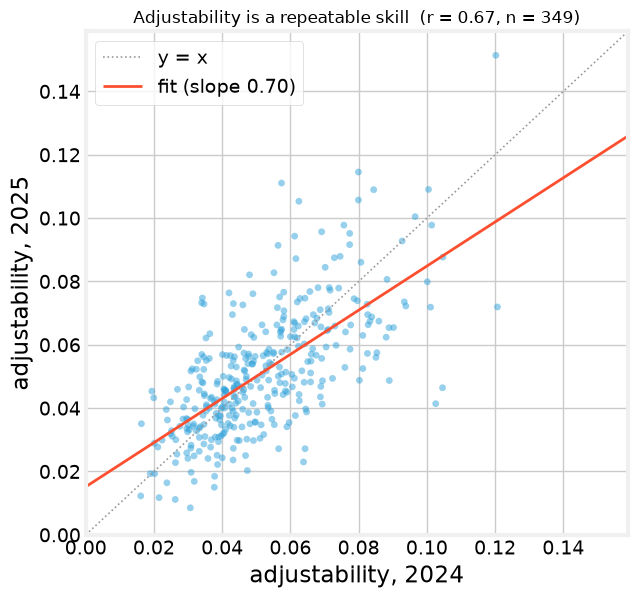

year-over-year: r = 0.668, n = 349 hitters in both seasons (>= 200 swings each)


In [5]:
# Recompute adjustability separately for 2024 and 2025 and correlate -- is it a repeatable skill?
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, str(ROOT / 'src'))
from adjustability import add_context, location_design, adj_r2, dummies, DIALS, KEY

cols = (['game_year', 'batter_full_name'] + KEY + ['balls', 'strikes', 'outs_when_up', 'plate_x',
        'plate_z', 'sz_top', 'sz_bot', 'pitch_type', 'on_1b_id', 'on_2b_id', 'on_3b_id'] + DIALS)
full = add_context(pd.read_parquet(DATA / 'swings_model.parquet', columns=cols))
AXES = {'count': ['balls', 'strikes'], 'gamestate': ['base_state', 'outs_when_up'], 'pitch': ['pitch_group']}
ALL = [c for v in AXES.values() for c in v]
MIN_SEASON = 200   # lower than the 400 pooled floor, since this is one season


def season_adjustability(yr):
    d = full[full.game_year == yr]
    rows = []
    for (bid, st), g in d.groupby(KEY, sort=False):
        if len(g) < MIN_SEASON:
            continue
        L = location_design(g)
        ys = {dd: g[dd].to_numpy(float) for dd in DIALS}
        a_loc = {dd: adj_r2(ys[dd], L) for dd in DIALS}
        a_full = {dd: adj_r2(ys[dd], np.column_stack([L, dummies(g, ALL)])) for dd in DIALS}
        rows.append({'batter_id': bid, 'batter_stand': st,
                     f'a{yr}': float(np.mean([max(0.0, a_full[dd] - a_loc[dd]) for dd in DIALS]))})
    return pd.DataFrame(rows)


m = season_adjustability(2024).merge(season_adjustability(2025), on=KEY)
r = np.corrcoef(m['a2024'], m['a2025'])[0, 1]
lim = [0, max(m['a2024'].max(), m['a2025'].max()) * 1.05]
b1, b0 = np.polyfit(m['a2024'], m['a2025'], 1)
with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(6.6, 6.2))
    ax.scatter(m['a2024'], m['a2025'], s=24, alpha=.5, color='#30a2da', edgecolor='none')
    ax.plot(lim, lim, color='#999999', ls=':', lw=1.2, label='y = x')
    ax.plot(np.array(lim), b0 + b1 * np.array(lim), color='#fc4f30', lw=2, label=f'fit (slope {b1:.2f})')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('adjustability, 2024')
    ax.set_ylabel('adjustability, 2025')
    ax.set_title(f'Adjustability is a repeatable skill  (r = {r:.2f}, n = {len(m)})', fontsize=12)
    ax.legend(loc='upper left')
    fig.tight_layout()
    fig.savefig(plot_path('adjustability_yoy_reliability.png'), dpi=130)
    plt.show()
print(f'year-over-year: r = {r:.3f}, n = {len(m)} hitters in both seasons (>= {MIN_SEASON} swings each)')

## Adjustability leaderboard (R · gt + headshots)

Rendered with **`gt` + `mlbplotR`** (MLBAM headshots, 538 theme) via `src/leaderboard_table.R`, reading `data/adjustability.parquet`. Colored on the headline **adjustability** (red = high, blue = low) with the domain fixed to the full qualified pool, so Top 10 reads all-red / Bottom 10 all-blue. The **Count axis** and **Pitch axis** columns show where each hitter's adjustability lives (each is that axis's unique contribution, net of the others). The two-strike payoff sits in the count axis.

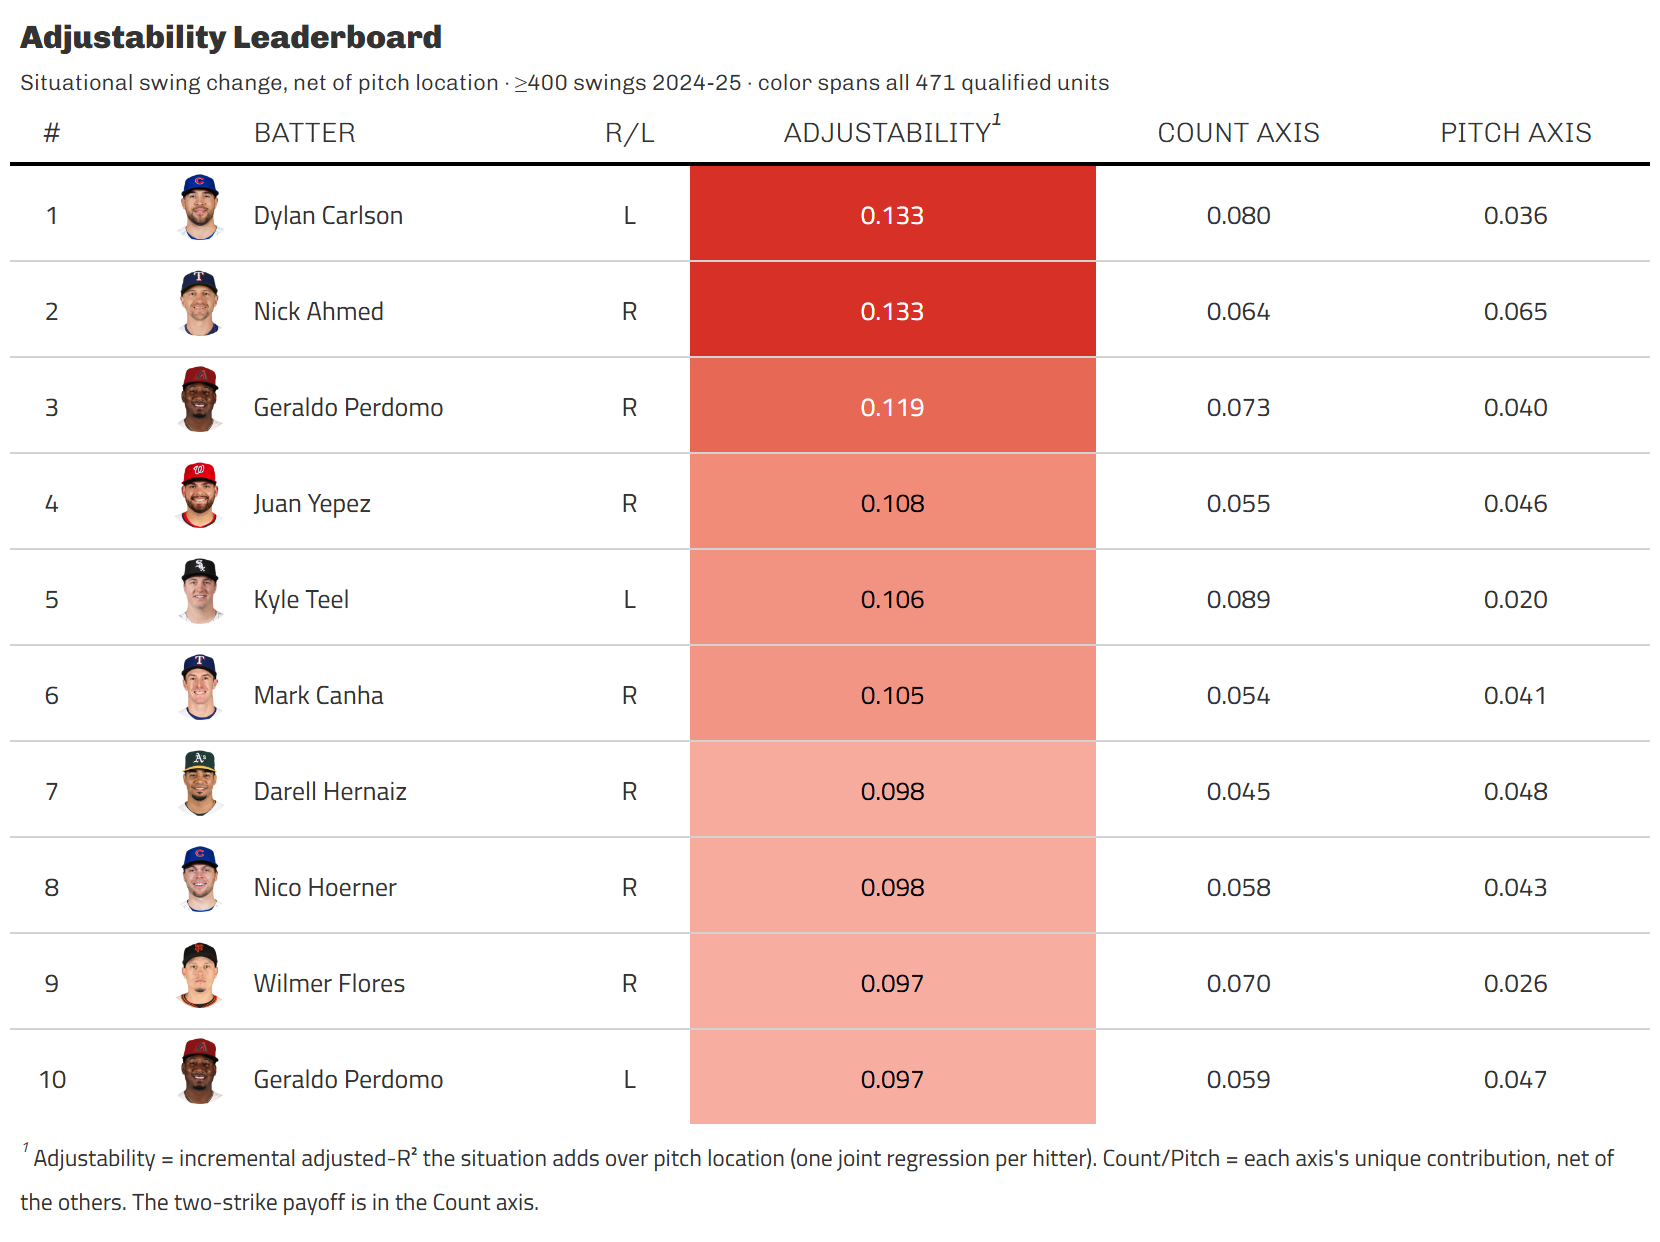

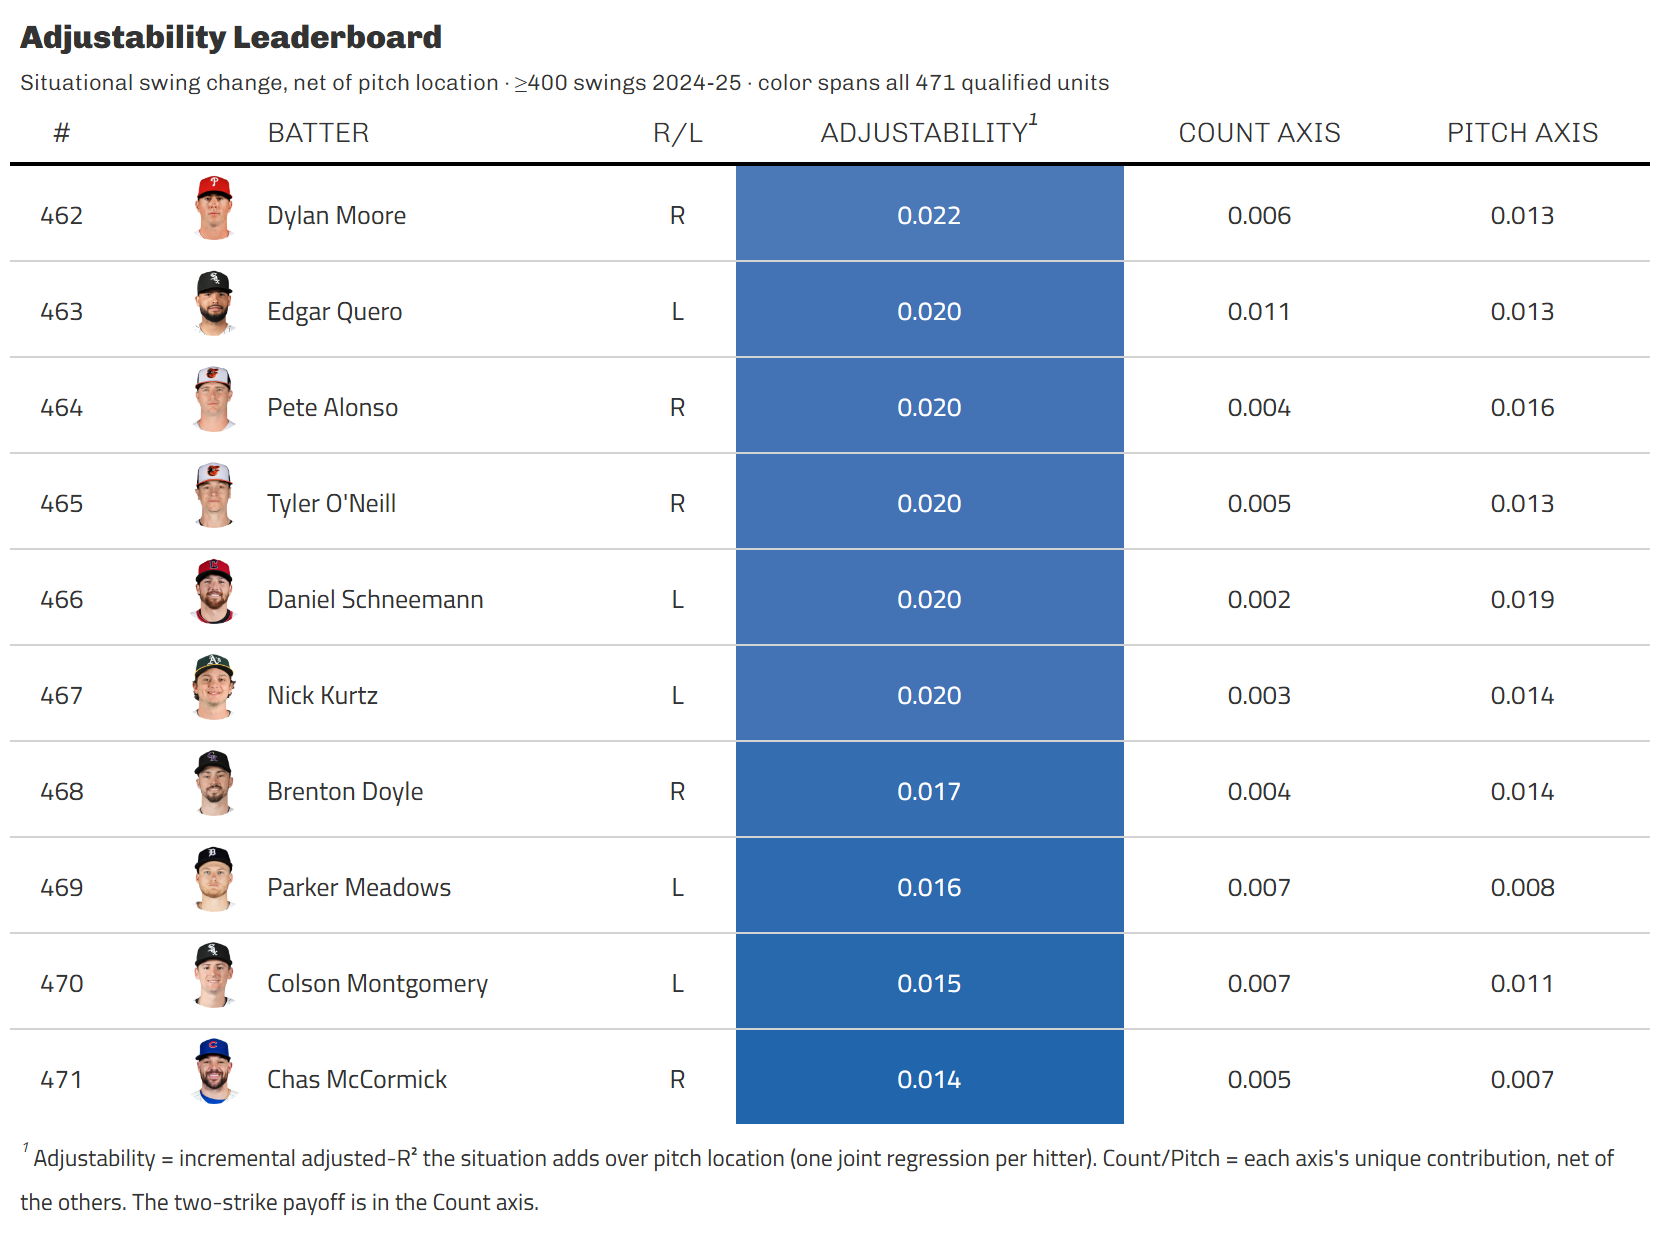

In [6]:
# Adjustability leaderboard via R. Runs src/leaderboard_table.R (which writes
# results/plots/adjustability/*.png) and displays the top/bottom tables inline. Rscript isn't on PATH
# here -> fall back to the R 4.6.0 install.
import subprocess, shutil
from IPython.display import Image, display

RSCRIPT = shutil.which('Rscript') or r'C:\Users\theo.an-yeung\AppData\Local\Programs\R\R-4.6.0\bin\Rscript.exe'
subprocess.run([RSCRIPT, 'src/leaderboard_table.R'], cwd=str(ROOT), check=True)
for png in ['adjustability_leaderboard_gt.png', 'adjustability_bottom_gt.png']:
    display(Image(filename=str(plot_path(png))))

## The payoff, in four numbers

The two-strike test comes down to four coefficients: the effect of **count adjustment** and **pitch adjustment** on each of the two penalties — run value and whiffs — from the self-matched model, holding swing quality, repertoire width, and playing time fixed. Only count adjustment matters: it significantly cuts both the run value a hitter loses and the whiffs he adds with two strikes, while pitch adjustment does neither. Each bar is a standardized coefficient — the change in the penalty, in standard deviations, per one-SD increase in that adjustment score; stars mark significance (*** p<0.001, ** p<0.01, * p<0.05).

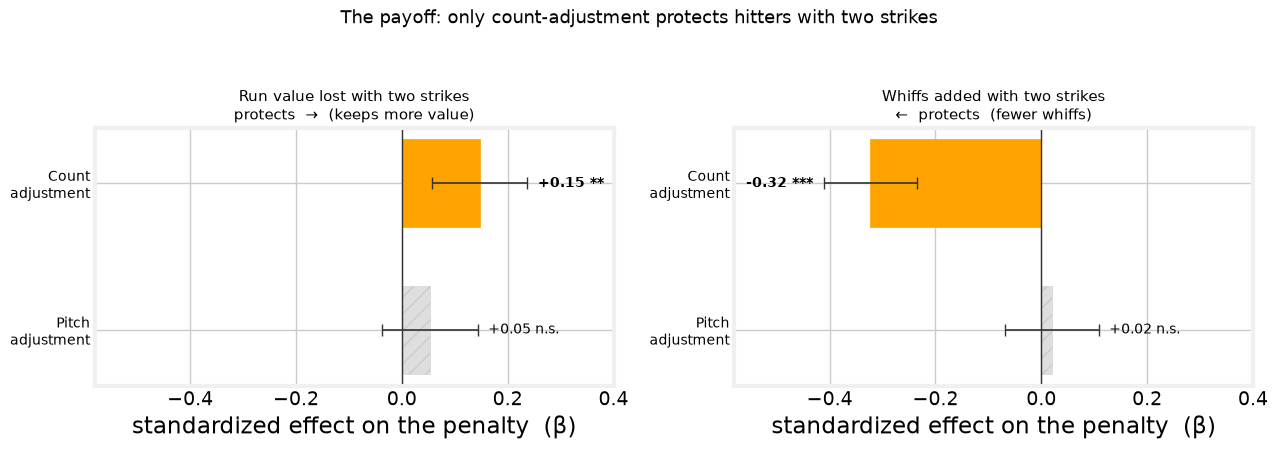

matched_rv -> count (0.147, 0.046, 0.0013)  pitch (0.053, 0.046, 0.245)
matched_whiff -> count (-0.323, 0.045, 0.0)  pitch (0.02, 0.045, 0.6644)


In [7]:
# ---- The payoff in four coefficients ----
# The whole two-strike finding is the effect of count- vs pitch-adjustment on the two penalties.
# Pull those four standardized coefficients straight from the committed results/payoff.md (self-matched
# model), and show them as a plain bar chart -- no controls, no coarse-vs-matched, no interaction.
import re
import numpy as np
import matplotlib.pyplot as plt


def coef(section, term):
    """(std_beta, se, p) for one term under a '### <section>' table in results/payoff.md."""
    text = (ROOT / 'results' / 'payoff.md').read_text(encoding='utf-8')
    body = re.split(r'^### ' + re.escape(section), text, flags=re.M)[1]
    row = next(ln for ln in body.splitlines() if ln.strip().startswith('| ' + term))
    cells = [c.strip() for c in row.strip('|').split('|')]
    return float(cells[1]), float(cells[2]), float(cells[4])


def stars(pv):
    return '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'n.s.'

GOLD, GREY = '#FFA300', '#b6b6b6'
panels = [('matched_rv', 'Run value lost with two strikes', 'protects  →  (keeps more value)'),
          ('matched_whiff', 'Whiffs added with two strikes', '←  protects  (fewer whiffs)')]
with plt.style.context(FT):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for ax, (sec, ttl, guide) in zip(axes, panels):
        for y, (term, lab, col) in enumerate([('adj_pitch', 'Pitch\nadjustment', GREY),
                                              ('adj_count', 'Count\nadjustment', GOLD)]):
            b, se, pv = coef(sec, term)
            sig = pv < 0.05
            ax.barh(y, b, height=.6, color=col, alpha=1.0 if sig else .45,
                    edgecolor=col, hatch=None if sig else '//')
            ax.errorbar(b, y, xerr=1.96 * se, color='#333333', lw=1.2, capsize=4, zorder=3)
            lx = b + np.sign(b) * (1.96 * se + 0.02)   # label sits just past the whisker
            ax.text(lx, y, f'{b:+.2f} {stars(pv)}', va='center',
                    ha='left' if b >= 0 else 'right', fontsize=10,
                    fontweight='bold' if sig else 'normal')
        ax.axvline(0, color='#333333', lw=1)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Pitch\nadjustment', 'Count\nadjustment'], fontsize=10)
        ax.set_xlim(-0.58, 0.40)
        ax.set_xlabel('standardized effect on the penalty  (β)')
        ax.set_title(f'{ttl}\n{guide}', fontsize=11)
    fig.suptitle('The payoff: only count-adjustment protects hitters with two strikes', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(plot_path('adjustability_payoff_coeffs.png'), dpi=130)
    plt.show()
for sec, *_ in panels:
    print(sec, '-> count', coef(sec, 'adj_count'), ' pitch', coef(sec, 'adj_pitch'))

## Adjustability is not just “good hitting” — the season-wide null

The two-strike payoff only means something if adjustability isn't just a stand-in for being a good hitter. The check: **if adjustability were simply a proxy for hitting well, it would predict season-long production** — and it doesn't. These two panels share the same y-axis (season run value per swing) so the contrast is direct:

- **Left — the power check.** Swing *quality* (Swing+) tracks season production steeply, so the outcome is clearly predictable and the test has power.
- **Right — adjustability.** Against that same outcome it is essentially flat. Adjusters do not out-produce over a full season.

So adjustability isn't general hitting quality wearing a different hat; its payoff (previous figure) is a targeted two-strike skill, exercised on too few pitches to move a season line.

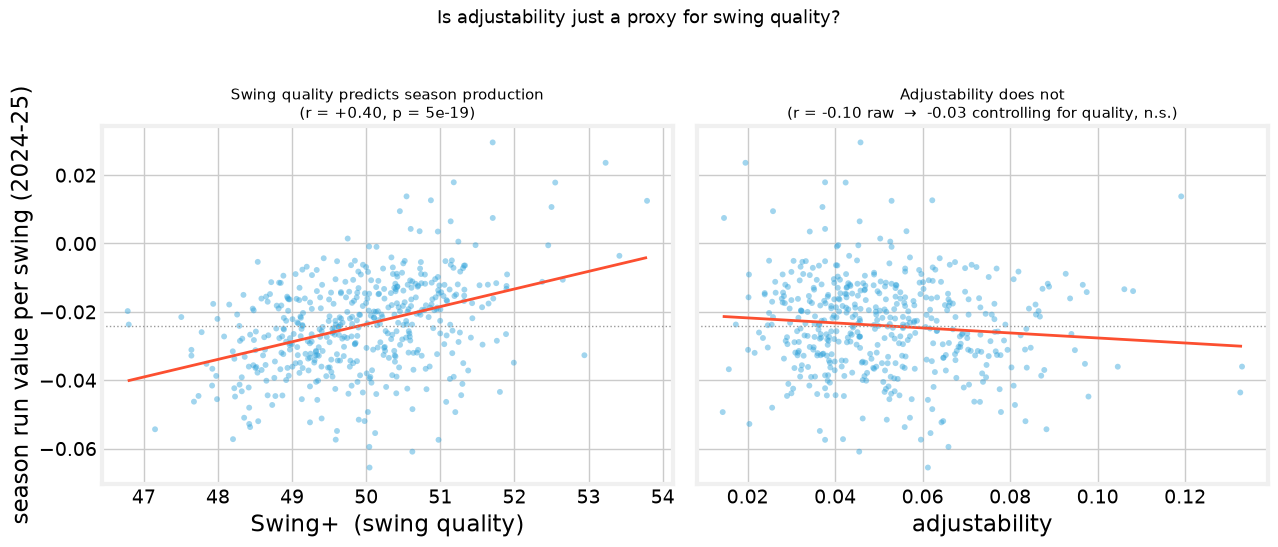

quality  r = +0.395 (p=4.5e-19);  adjustability raw r = -0.099, partial r|quality = -0.031 (p=0.50)


In [8]:
# ---- Season-wide null: adjustability is not a proxy for hitting well ----
# Same outcome (season run value / swing) on both panels. LEFT: swing quality predicts it (power
# check). RIGHT: adjustability does not -- and the faint raw negative slope vanishes once we control
# for swing quality (partial r), matching the season-wide regression's null. Per (batter, stand),
# 2024-25, the 471 qualified units.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

KEY = ['batter_id', 'batter_stand']
SEASONS = [2024, 2025]

adj = pd.read_parquet(DATA / 'adjustability.parquet', columns=KEY + ['adjustability'])
swp = pd.read_parquet(DATA / 'xrv_swings.parquet', columns=KEY + ['game_year', 'xrv_grade'])
swp = (swp[swp.game_year.isin(SEASONS)].groupby(KEY)['xrv_grade'].mean()
       .rename('swing_plus').reset_index())
rv = pd.read_parquet(DATA / 'swings_model.parquet', columns=KEY + ['game_year', 'delta_run_exp'])
rv = (rv[rv.game_year.isin(SEASONS)].groupby(KEY)['delta_run_exp'].mean()
      .rename('rv_per_swing').reset_index())
d = adj.merge(swp, on=KEY).merge(rv, on=KEY)


def fit_resid(y, x):
    b1, b0 = np.polyfit(x, y, 1)
    return y - (b0 + b1 * x)

# partial correlation of adjustability with season RV, controlling for swing quality
r_raw, _ = stats.pearsonr(d['adjustability'], d['rv_per_swing'])
r_part, p_part = stats.pearsonr(fit_resid(d['adjustability'].values, d['swing_plus'].values),
                                fit_resid(d['rv_per_swing'].values, d['swing_plus'].values))
r_q, p_q = stats.pearsonr(d['swing_plus'], d['rv_per_swing'])

titles = ['Swing quality predicts season production\n'
          f'(r = {r_q:+.2f}, p = {p_q:.0e})',
          'Adjustability does not\n'
          f'(r = {r_raw:+.2f} raw  →  {r_part:+.2f} controlling for quality, n.s.)']
with plt.style.context(FT):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)
    for ax, col, title in zip(axes, ['swing_plus', 'adjustability'], titles):
        b1, b0 = np.polyfit(d[col], d['rv_per_swing'], 1)
        xs = np.array([d[col].min(), d[col].max()])
        ax.scatter(d[col], d['rv_per_swing'], s=18, alpha=.45, color='#30a2da', edgecolor='none')
        ax.plot(xs, b0 + b1 * xs, color='#fc4f30', lw=2)
        ax.axhline(d['rv_per_swing'].mean(), color='#999999', lw=1, ls=':')
        ax.set_title(title, fontsize=11)
    axes[0].set_xlabel('Swing+  (swing quality)')
    axes[1].set_xlabel('adjustability')
    axes[0].set_ylabel('season run value per swing (2024-25)')
    fig.suptitle('Is adjustability just a proxy for swing quality?',
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(plot_path('adjustability_season_null.png'), dpi=130)
    plt.show()
print(f'quality  r = {r_q:+.3f} (p={p_q:.1e});  adjustability raw r = {r_raw:+.3f}, '
      f'partial r|quality = {r_part:+.3f} (p={p_part:.2f})')

## Where does adjustability live? — count axis vs pitch axis

Each axis is its **unique** contribution to the swing, net of pitch location and the other axes (so `adj_count` holds pitch type fixed). This scatter shows the count and pitch axes are only weakly related — they're distinct skills, and the two-strike payoff lives entirely in **adj_count**. (Under the v4 metric the headline `adjustability` is count-led, not pitch-dominated — a hitter high on the count axis is the one who protects at two strikes.)

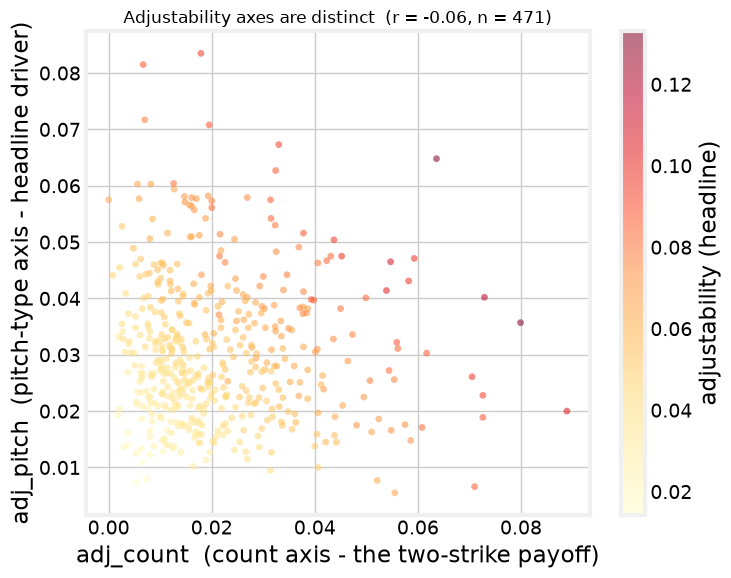

adj_count vs adj_pitch: r = -0.056, n = 471


In [9]:
# adj_count vs adj_pitch, colored by the headline adjustability. Weak relationship = the two axes
# are distinct skills; the payoff (two-strike protection) is the count axis, the headline is pitch.
import numpy as np
import matplotlib.pyplot as plt

adj = pd.read_parquet(DATA / 'adjustability.parquet',
                      columns=['label', 'batter_stand', 'adjustability', 'adj_count', 'adj_pitch'])
r = np.corrcoef(adj['adj_count'], adj['adj_pitch'])[0, 1]
with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(7.5, 6))
    sc = ax.scatter(adj['adj_count'], adj['adj_pitch'], s=24, alpha=.55,
                    c=adj['adjustability'], cmap='YlOrRd', edgecolor='none')
    ax.set_xlabel('adj_count  (count axis - the two-strike payoff)')
    ax.set_ylabel('adj_pitch  (pitch-type axis - headline driver)')
    ax.set_title(f'Adjustability axes are distinct  (r = {r:.2f}, n = {len(adj)})', fontsize=12)
    fig.colorbar(sc, label='adjustability (headline)')
    fig.tight_layout()
    fig.savefig(plot_path('adjustability_axes_scatter.png'), dpi=130)
    plt.show()
print(f'adj_count vs adj_pitch: r = {r:.3f}, n = {len(adj)}')